# Notebook 3 — Explainability & Model Export
## Predictive Aircraft Maintenance — Track B

Rebuilds the same pipeline as Notebook 2 (same seed, reproducible), then focuses on **explainability** (two independent feature-importance methods) and **exporting the model** for the backend.

---


## 1 · Setup & pipeline (same as Notebook 2)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings, os
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 12})

In [2]:
# 📌 Same mount as Session 1 — adjust the path if your Drive folder differs
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/DATA_DIR/'


Mounted at /content/drive


In [3]:
# Same column names as Session 1
COL_NAMES = (
    ['unit_number', 'time_in_cycles',
     'op_setting_1', 'op_setting_2', 'op_setting_3']
    + [f'sensor_{i:02d}' for i in range(1, 22)]
)

def load_cmapss(filepath):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    df.columns = COL_NAMES
    return df

In [4]:
train_df = load_cmapss(DATA_DIR + 'train_FD001.txt')

# RUL construction — identical to Session 1
engine_lives = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
engine_lives.rename(columns={'time_in_cycles': 'max_cycles'}, inplace=True)
train_df = train_df.merge(engine_lives, on='unit_number')
train_df['RUL_raw'] = train_df['max_cycles'] - train_df['time_in_cycles']
train_df['RUL'] = train_df['RUL_raw'].clip(upper=125)

print(f'Loaded {train_df.shape[0]:,} rows across {train_df["unit_number"].nunique()} engines')

Loaded 20,631 rows across 100 engines


In [5]:
# Engine-level split — identical seed and proportions as Session 1 (80 / 10 / 10)
np.random.seed(RANDOM_STATE)
all_engines = train_df['unit_number'].unique()
np.random.shuffle(all_engines)

train_engines = all_engines[:80]
val_engines   = all_engines[80:90]
test_engines  = all_engines[90:]

df_train = train_df[train_df['unit_number'].isin(train_engines)].copy()
df_val   = train_df[train_df['unit_number'].isin(val_engines)].copy()
df_test  = train_df[train_df['unit_number'].isin(test_engines)].copy()

assert set(train_engines) & set(val_engines)  == set(), 'Leakage detected!'
assert set(train_engines) & set(test_engines) == set(), 'Leakage detected!'

print(f'Train: {len(train_engines)} engines — {len(df_train):,} rows')
print(f'Val:   {len(val_engines)} engines — {len(df_val):,} rows')
print(f'Test:  {len(test_engines)} engines — {len(df_test):,} rows')
print('✓ No leakage — every engine belongs to exactly one set.')

Train: 80 engines — 16,340 rows
Val:   10 engines — 2,082 rows
Test:  10 engines — 2,209 rows
✓ No leakage — every engine belongs to exactly one set.


In [6]:
# Which sensors carry real signal? Decide using TRAIN ONLY — never val/test.
sensor_cols = [c for c in df_train.columns if c.startswith('sensor_')]

sensor_range = df_train[sensor_cols].max() - df_train[sensor_cols].min()
non_const = sensor_range[sensor_range > 1e-9].index.tolist()

mins, maxs = df_train[non_const].min(), df_train[non_const].max()
norm = (df_train[non_const] - mins) / (maxs - mins)
var_norm = norm.var().sort_values()

NORM_THRESH = 0.02
keep_sensors = var_norm[var_norm >= NORM_THRESH].index.tolist()
drop_sensors = var_norm[var_norm < NORM_THRESH].index.tolist()

print(f'Keeping {len(keep_sensors)} informative sensors')
print(f'Dropping {len(drop_sensors)} near-constant sensors: {drop_sensors}')

Keeping 7 informative sensors
Dropping 8 near-constant sensors: ['sensor_09', 'sensor_14', 'sensor_13', 'sensor_08', 'sensor_17', 'sensor_03', 'sensor_06', 'sensor_20']


In [7]:
ROLL_WINDOW = 8  # cycles — a compromise: short enough to react, long enough to smooth noise

def add_rolling_features(df, sensors, window=ROLL_WINDOW):
    df = df.sort_values(['unit_number', 'time_in_cycles']).copy()
    for s in sensors:
        grouped = df.groupby('unit_number')[s]
        df[f'{s}_rmean'] = grouped.transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{s}_rstd']  = grouped.transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

df_train_fe = add_rolling_features(df_train, keep_sensors)
df_val_fe   = add_rolling_features(df_val,   keep_sensors)
df_test_fe  = add_rolling_features(df_test,  keep_sensors)

print(f'Train shape after feature engineering: {df_train_fe.shape}')
assert df_train_fe.isnull().sum().sum() == 0, 'Unexpected NaNs after rolling features!'
print('✓ No missing values.')

Train shape after feature engineering: (16340, 43)
✓ No missing values.


In [10]:
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
rolling_cols = [f'{s}_rmean' for s in keep_sensors] + [f'{s}_rstd' for s in keep_sensors]
feature_cols = op_cols + keep_sensors + rolling_cols

print(f'Final feature list: {len(feature_cols)} columns')
print(feature_cols)

X_train, y_train = df_train_fe[feature_cols], df_train_fe['RUL']
X_val,   y_val   = df_val_fe[feature_cols],   df_val_fe['RUL']
X_test,  y_test  = df_test_fe[feature_cols],  df_test_fe['RUL']

Final feature list: 24 columns
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_07', 'sensor_15', 'sensor_21', 'sensor_02', 'sensor_12', 'sensor_04', 'sensor_11', 'sensor_07_rmean', 'sensor_15_rmean', 'sensor_21_rmean', 'sensor_02_rmean', 'sensor_12_rmean', 'sensor_04_rmean', 'sensor_11_rmean', 'sensor_07_rstd', 'sensor_15_rstd', 'sensor_21_rstd', 'sensor_02_rstd', 'sensor_12_rstd', 'sensor_04_rstd', 'sensor_11_rstd']


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=feature_cols, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols, index=X_test.index)

# 📌 fit_transform on train, transform (no refit) on val/test — this line is the one
# students most often get wrong by copy-pasting fit_transform everywhere.
print('Train mean after scaling (should be ~0):', round(X_train_scaled.mean().abs().max(), 6))

Train mean after scaling (should be ~0): 0.0


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, train_time, name):
    """Compute MAE, RMSE, R2 and store training time — same scorecard for every model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:<20} MAE={mae:6.2f}   RMSE={rmse:6.2f}   R2={r2:6.3f}   time={train_time:.3f}s')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'train_time_s': train_time}

results = []  # every model's scorecard will be appended here

# Baseline: always predict the TRAIN mean RUL (never computed on val/test — same anti-leakage rule)
baseline_value = df_train_fe['RUL'].mean()
baseline_pred_val = np.full(len(df_val_fe), baseline_value)

results.append(evaluate(df_val_fe['RUL'], baseline_pred_val, 0.0, 'Baseline (mean)'))

Baseline (mean)      MAE= 37.04   RMSE= 41.65   R2=-0.000   time=0.000s


In [12]:
from sklearn.linear_model import LinearRegression

t0 = time.time()
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_time = time.time() - t0

lin_pred_val = lin_model.predict(X_val_scaled)
results.append(evaluate(y_val, lin_pred_val, lin_time, 'Linear Regression'))

Linear Regression    MAE= 18.73   RMSE= 22.79   R2= 0.701   time=0.039s


In [13]:
from sklearn.tree import DecisionTreeRegressor

t0 = time.time()
tree_model = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
tree_model.fit(X_train_scaled, y_train)
tree_time = time.time() - t0

tree_pred_val = tree_model.predict(X_val_scaled)
results.append(evaluate(y_val, tree_pred_val, tree_time, 'Decision Tree'))

Decision Tree        MAE= 16.48   RMSE= 21.86   R2= 0.725   time=0.224s


In [14]:
from sklearn.ensemble import RandomForestRegressor

t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_time = time.time() - t0

rf_pred_val = rf_model.predict(X_val_scaled)
results.append(evaluate(y_val, rf_pred_val, rf_time, 'Random Forest'))

Random Forest        MAE= 16.08   RMSE= 21.07   R2= 0.744   time=49.300s


In [15]:
from xgboost import XGBRegressor

t0 = time.time()
xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          random_state=RANDOM_STATE, n_jobs=-1,
                          objective='reg:squarederror')
xgb_model.fit(X_train_scaled, y_train)
xgb_time = time.time() - t0

xgb_pred_val = xgb_model.predict(X_val_scaled)
results.append(evaluate(y_val, xgb_pred_val, xgb_time, 'XGBoost'))

XGBoost              MAE= 16.03   RMSE= 21.12   R2= 0.743   time=0.770s


In [16]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df

,model,MAE,RMSE,R2,train_time_s
0,XGBoost,16.033960,21.118039,0.742801,0.769687
1,Random Forest,16.081058,21.072829,0.743901,49.299700
2,Decision Tree,16.475326,21.855948,0.724513,0.223992
3,Linear Regression,18.730000,22.787591,0.700526,0.039078
4,Baseline (mean),37.039408,41.647206,-0.000309,0.000000


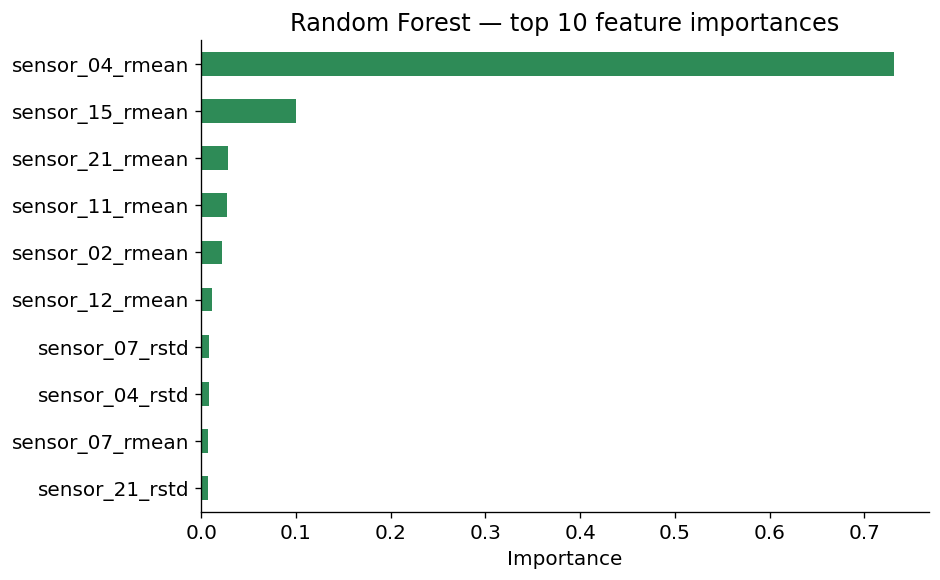

In [19]:
# Method 1 — built-in feature importance (tree-based models only)
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#2E8B57')
ax.set_title('Random Forest — top 10 feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', bbox_inches='tight')
plt.show()

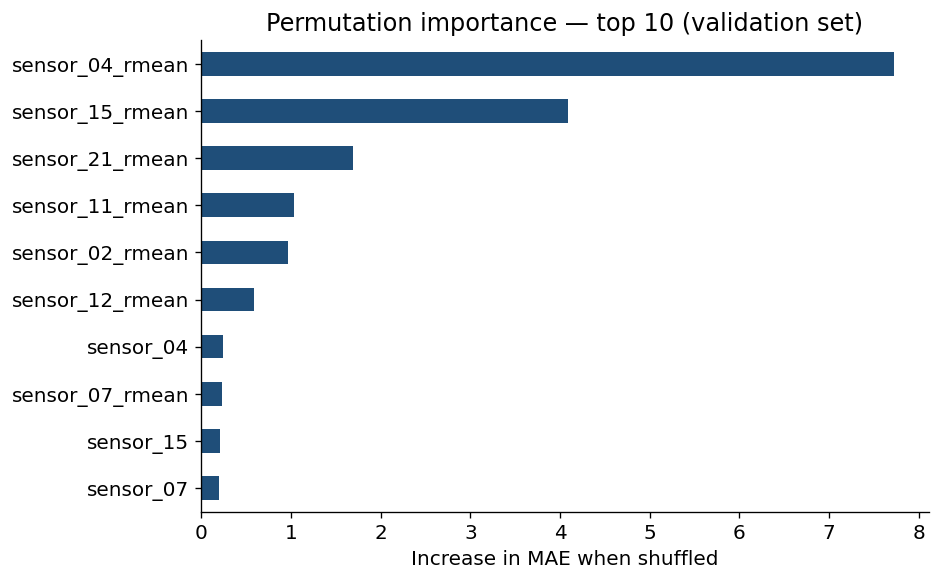

In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_model, X_val_scaled, y_val, n_repeats=10,
                               random_state=RANDOM_STATE, scoring='neg_mean_absolute_error')
perm_importances = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
perm_importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#1F4E79')
ax.set_title('Permutation importance — top 10 (validation set)')
ax.set_xlabel('Increase in MAE when shuffled')
plt.tight_layout()
plt.savefig('outputs/permutation_importance.png', bbox_inches='tight')
plt.show()

In [21]:
def rul_to_risk(rul):
    if rul < 30:
        return 'High'
    elif rul < 70:
        return 'Medium'
    else:
        return 'Low'

def recommendation(risk):
    return {'High': 'Prioritise this engine for inspection.',
            'Medium': 'Schedule a closer check soon.',
            'Low': 'No immediate action needed.'}[risk]

# 📌 These thresholds are an assumption we document, not a value read from the data
# (the brief is explicit: no cost or scheduling data is provided by NASA).
example_idx = X_test_scaled.index[0]
example_engine_id = df_test_fe.loc[example_idx, 'unit_number']
example_pred = xgb_model.predict(X_test_scaled.loc[[example_idx]])[0]
example_risk = rul_to_risk(example_pred)

print(f'Engine ID: {example_engine_id}')
print(f'Predicted RUL: {example_pred:.0f} cycles')
print(f'Risk level: {example_risk}')
print(f'Recommendation: {recommendation(example_risk)}')

Engine ID: 15
Predicted RUL: 130 cycles
Risk level: Low
Recommendation: No immediate action needed.


---
## Save the model — export artifacts for the backend

Writes the trained model, scaler, feature list and metadata to `models/` so the FastAPI backend can `joblib.load` them instead of retraining.


In [ ]:
import joblib, json, os
from datetime import date

os.makedirs('models', exist_ok=True)

# pick the best real model by MAE
real_models = results_df[results_df['model'] != 'Baseline (mean)']
best_name = real_models.iloc[0]['model']
best_row  = real_models.iloc[0]
best_model = {'Linear Regression': lin_model, 'Decision Tree': tree_model,
              'Random Forest': rf_model, 'XGBoost': xgb_model}[best_name]

joblib.dump(best_model, 'models/model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
with open('models/feature_cols.json','w') as f:
    json.dump(feature_cols, f, indent=2)
with open('models/model_metadata.json','w') as f:
    json.dump({'algorithm':best_name,'training_date':str(date.today()),
               'validation_mae':float(best_row['MAE']),'validation_rmse':float(best_row['RMSE']),
               'validation_r2':float(best_row['R2']),'n_features':len(feature_cols)}, f, indent=2)
print('Saved:', os.listdir('models'))


### Download the exported files


In [ ]:
from google.colab import files
import shutil
shutil.make_archive('models_export','zip','models')
files.download('models_export.zip')
